In [2]:
!pip install pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 52.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 50.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 48.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 40.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 43.9 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 42.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [seaborn]9/10 [seaborn]ib]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python3 -m pip install --upgrade pip


All Matches Shape: (326, 36)
NCAA Rankings Shape: (12409, 23)
Combine Results Shape: (1277, 18)

All Matches Columns:
Index(['Season', 'Name', 'Position', 'Team', 'Conference', 'AveragePPA All',
       'AveragePPA Pass', 'AveragePPA Rush', 'AveragePPA FirstDown',
       'AveragePPA SecondDown', 'AveragePPA ThirdDown',
       'AveragePPA StandardDowns', 'AveragePPA PassingDowns', 'TotalPPA All',
       'TotalPPA Pass', 'TotalPPA Rush', 'TotalPPA FirstDown',
       'TotalPPA SecondDown', 'TotalPPA ThirdDown', 'TotalPPA StandardDowns',
       'TotalPPA PassingDowns', 'index_combine', 'Season_combine',
       'Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Arm (inches)',
       'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)',
       'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)',
       'Shuttle (seconds)', 'Overall Pick', 'Combine Participation'],
      dtype='str')
                            Season  AveragePPA All  AveragePPA Pass  \
Season             

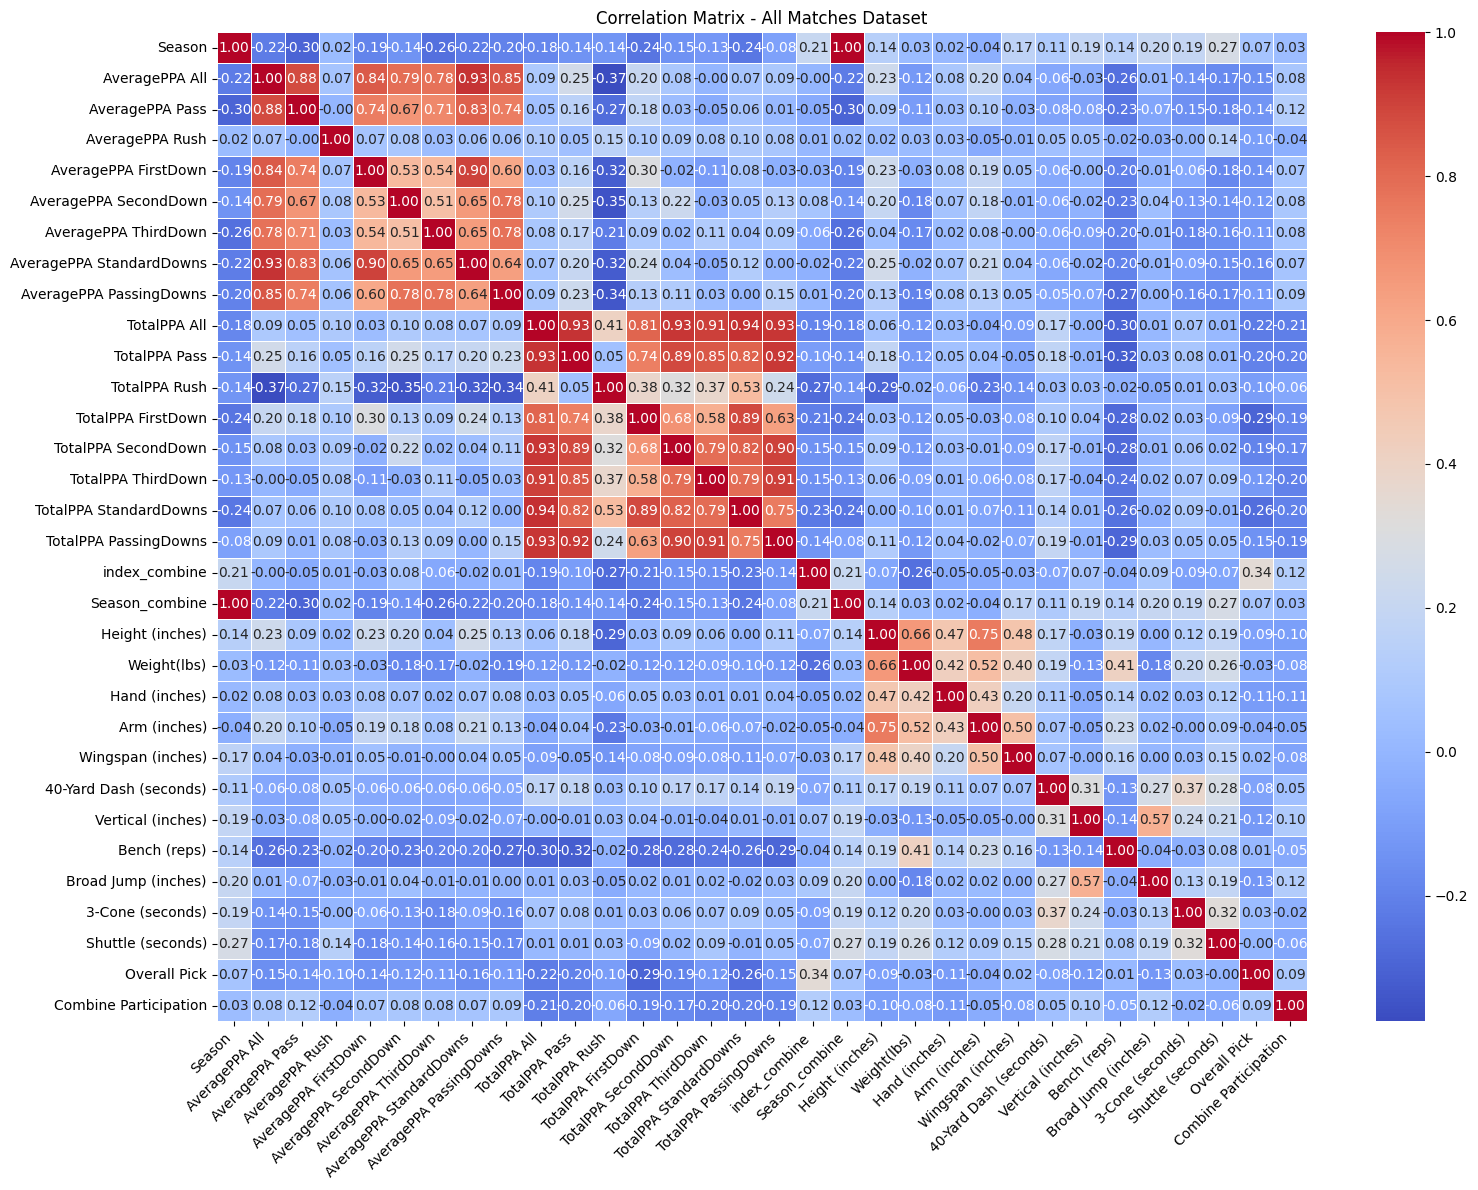

In [4]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# IMPORT DATASETS
# =========================
all_matches = pd.read_csv("All Matches.csv", encoding="latin1")
ncaa_rankings = pd.read_csv("All NCAA Player Rankings.csv", encoding="latin1")
combine_results = pd.read_csv("All NFL Scouting Combine Results.csv", encoding="latin1")

# =========================
# VIEW DATASET INFO
# =========================
print("All Matches Shape:", all_matches.shape)
print("NCAA Rankings Shape:", ncaa_rankings.shape)
print("Combine Results Shape:", combine_results.shape)

print("\nAll Matches Columns:")
print(all_matches.columns)

# =========================
# CREATE CORRELATION MATRIX
# USING ALL MATCHES DATASET
# =========================

# Keep only numeric columns
numeric_df = all_matches.select_dtypes(include=['number'])

# Create correlation matrix
corr_matrix = numeric_df.corr()

# =========================
# DISPLAY CORRELATION MATRIX
# =========================
print(corr_matrix)

# =========================
# VISUALIZE CORRELATION MATRIX
# =========================
plt.figure(figsize=(16,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix - All Matches Dataset")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

                        AveragePPA All  Height (inches)  Weight(lbs)  \
AveragePPA All                1.000000         0.232726    -0.118720   
Height (inches)               0.232726         1.000000     0.656547   
Weight(lbs)                  -0.118720         0.656547     1.000000   
Hand (inches)                 0.082520         0.471323     0.420840   
Arm (inches)                  0.196005         0.752519     0.516344   
Wingspan (inches)             0.037270         0.481529     0.398071   
40-Yard Dash (seconds)       -0.063894         0.174590     0.189141   
Vertical (inches)            -0.028372        -0.029662    -0.128351   
Bench (reps)                 -0.260435         0.187247     0.409549   
Broad Jump (inches)           0.010276         0.003992    -0.181702   
3-Cone (seconds)             -0.139503         0.119870     0.203281   
Shuttle (seconds)            -0.170608         0.189345     0.255412   
Overall Pick                 -0.154774        -0.086866    -0.03

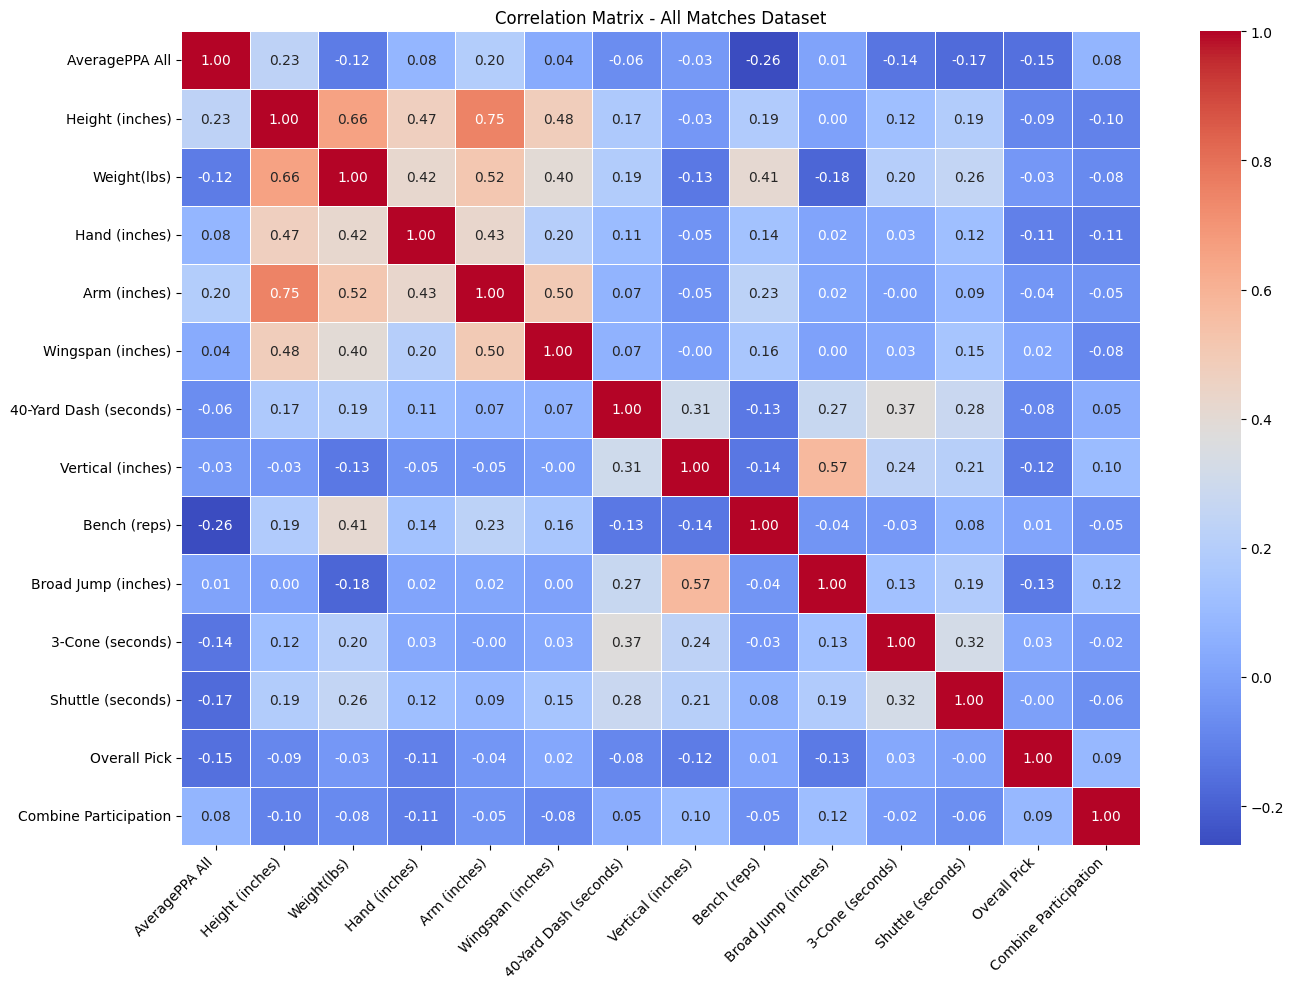

In [6]:
# =========================
# IMPORT LIBRARIES
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# IMPORT DATASETS
# =========================
all_matches = pd.read_csv("All Matches.csv", encoding="latin1")

# =========================
# DROP UNWANTED COLUMNS
# =========================
columns_to_remove = [
    "Season",
    "index_combine",
    "Season_combine"
]

# Remove all PPA columns except AveragePPA All
for col in all_matches.columns:
    if "PPA" in col and col != "AveragePPA All":
        columns_to_remove.append(col)

# Drop columns if they exist
all_matches = all_matches.drop(
    columns=[col for col in columns_to_remove if col in all_matches.columns],
    errors="ignore"
)

# =========================
# KEEP ONLY NUMERIC COLUMNS
# =========================
numeric_df = all_matches.select_dtypes(include=['number'])

# =========================
# CREATE CORRELATION MATRIX
# =========================
corr_matrix = numeric_df.corr()

# =========================
# PRINT CORRELATION MATRIX
# =========================
print(corr_matrix)

# =========================
# VISUALIZE CORRELATION MATRIX
# =========================
plt.figure(figsize=(14,10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix - All Matches Dataset")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
print(rankings_df["Position"].value_counts())

Position
WR    5223
RB    3150
TE    2084
QB    1918
FB      34
Name: count, dtype: int64


In [13]:
print(merged_df["Position"].value_counts())

Position
WR    263
RB    134
TE    125
QB     88
Name: count, dtype: int64


          40-Yard Dash (seconds) Z  Vertical (inches) Z  Bench (reps) Z  \
Position                                                                  
C                             0.97                -0.78            0.25   
CB                           -0.58                 0.46           -0.86   
DE                            0.10                -0.19            0.13   
DT                            0.69                -0.80            0.53   
EDGE                         -0.05                -0.02            0.81   
FB                           -0.31                -0.08           -0.26   
G                             1.10                -1.02            0.68   
IOL                           0.96                -0.78            0.65   
K                            -0.40                 0.15           -0.43   
LB                           -0.31                 0.28            0.28   
LS                            0.79                -0.87           -1.22   
OG                       

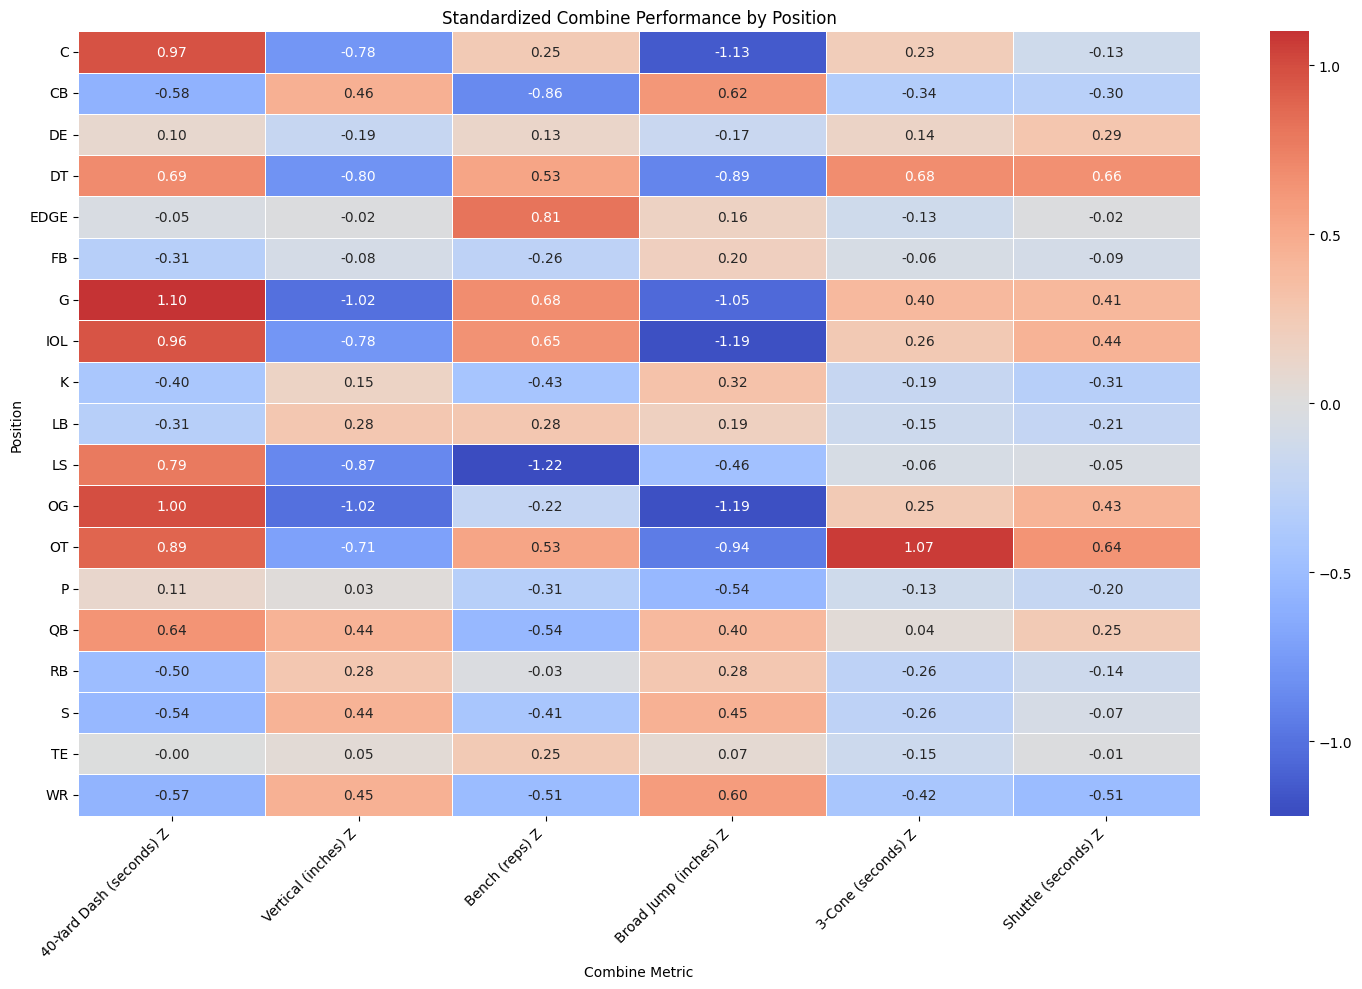

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# IMPORT FULL COMBINE DATASET
# =========================
combine_df = pd.read_csv(
    "All NFL Scouting Combine Results.csv",
    encoding="latin1"
)

# =========================
# CLEAN POSITION LABELS
# =========================
combine_df["Position"] = combine_df["Position"].replace({
    "SAF": "S",
    "DB": "CB",
    "DL": "DT",
    "OLB": "LB",
    "ILB": "LB",
    "OC": "C",
    "OL": "OT"
})

# =========================
# COMBINE METRICS
# =========================
metrics = [
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)"
]

# Convert metrics to numeric
for col in metrics:
    combine_df[col] = pd.to_numeric(
        combine_df[col],
        errors="coerce"
    )

# =========================
# STANDARDIZE METRICS (Z-SCORES)
# =========================
z_df = combine_df.copy()

for col in metrics:
    z_df[col + " Z"] = (
        (z_df[col] - z_df[col].mean())
        / z_df[col].std()
    )

z_metrics = [col + " Z" for col in metrics]

# =========================
# AVERAGE Z-SCORES BY POSITION
# =========================
position_matrix = (
    z_df
    .groupby("Position")[z_metrics]
    .mean()
    .round(2)
    .sort_index()
)

print(position_matrix)

# =========================
# HEATMAP
# =========================
plt.figure(figsize=(15, 10))

sns.heatmap(
    position_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Standardized Combine Performance by Position")
plt.xlabel("Combine Metric")
plt.ylabel("Position")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()